In [70]:
import torch
import torch.nn as nn
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [71]:

path1 = kagglehub.dataset_download("novandraanugrah/bitcoin-historical-datasets-2018-2024")

print("The dataset is downloaded to:", path1)

files1 = os.listdir(path1)
print("Folder contents:", files1)

The dataset is downloaded to: C:\Users\mmapa\.cache\kagglehub\datasets\novandraanugrah\bitcoin-historical-datasets-2018-2024\versions\419
Folder contents: ['btc_15m_data_2018_to_2025.csv', 'btc_1d_data_2018_to_2025.csv', 'btc_1h_data_2018_to_2025.csv', 'btc_4h_data_2018_to_2025.csv']


In [72]:
bitcoin = pd.read_csv(os.path.join(path1, "btc_1d_data_2018_to_2025.csv"))

In [73]:
bitcoin.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [74]:
bitcoin.tail()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
2984,2026-03-04 00:00:00.000000 UTC,68338.01,68909.34,67857.61,68543.03,1831.35805,2026-03-04 23:59:59.999000 UTC,1.250343e+08,501562,913.83373,6.242022e+07,0
2985,2026-03-05 00:00:00.000000 UTC,72666.77,73306.82,72553.65,72589.46,1646.99020,2026-03-05 23:59:59.999000 UTC,1.199628e+08,504466,801.89199,5.841682e+07,0
2986,2026-03-06 00:00:00.000000 UTC,70891.02,71261.29,70344.03,71152.82,1651.57947,2026-03-06 23:59:59.999000 UTC,1.170352e+08,412082,864.12652,6.126500e+07,0
2987,2026-03-07 00:00:00.000000 UTC,68114.02,68394.09,68105.73,68251.56,914.93110,2026-03-07 23:59:59.999000 UTC,6.241224e+07,138700,463.00624,3.158072e+07,0
2988,2026-03-08 00:00:00.000000 UTC,67262.91,67481.96,67090.00,67329.41,1095.93084,2026-03-08 23:59:59.999000 UTC,7.372613e+07,142092,656.49587,4.415627e+07,0


In [75]:
bitcoin_close = bitcoin[['Close time', 'Close']]


In [76]:
bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])
#move to datetime

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\2044088185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])


In [77]:
bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date
# move to date

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\4100889944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date


In [78]:
bitcoin_close = bitcoin_close.set_index('Close time')
bitcoin_close.index = pd.to_datetime(bitcoin_close.index)# this is important, it fixes the index

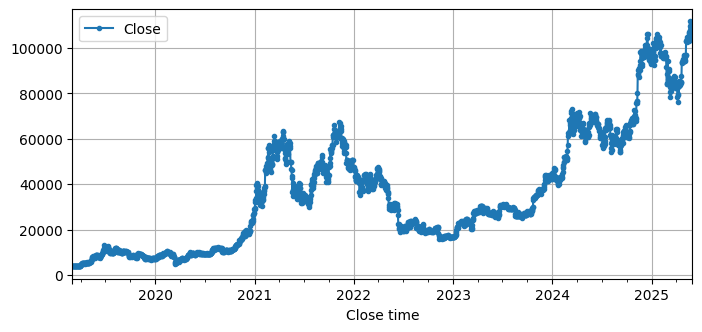

In [79]:
bitcoin_close["2019-03":"2025-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

In [100]:
from torch.utils.data import DataLoader
btc_train = torch.FloatTensor(bitcoin_close[['Close']]["2018-01":"2024-12"].values) / 1e5
btc_valid = torch.FloatTensor(bitcoin_close[['Close']]["2025-01":"2025-06"].values) / 1e5
btc_test = torch.FloatTensor(bitcoin_close[['Close']]["2025-07":].values) / 1e5


In [81]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end] # wszystkie wartosci "okna"
        target = self.series[end] #wartosc po oknie
        return window, target

In [101]:
window_length = 56
train_set = TimeSeriesDataset(btc_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=False)
valid_set = TimeSeriesDataset(btc_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
test_set = TimeSeriesDataset(btc_test, window_length)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [83]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [84]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

linear model

In [102]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=150)

Epoch 1/150, train loss: 0.0062, train metric: 0.0504, valid metric: 0.0849
Epoch 2/150, train loss: 0.0056, train metric: 0.0606, valid metric: 0.0936
Epoch 3/150, train loss: 0.0048, train metric: 0.0448, valid metric: 0.0950
Epoch 4/150, train loss: 0.0048, train metric: 0.0458, valid metric: 0.0888
Epoch 5/150, train loss: 0.0043, train metric: 0.0438, valid metric: 0.0804
Epoch 6/150, train loss: 0.0035, train metric: 0.0398, valid metric: 0.0712
Epoch 7/150, train loss: 0.0028, train metric: 0.0350, valid metric: 0.0621
Epoch 8/150, train loss: 0.0021, train metric: 0.0303, valid metric: 0.0539
Epoch 9/150, train loss: 0.0016, train metric: 0.0259, valid metric: 0.0474
Epoch 10/150, train loss: 0.0012, train metric: 0.0222, valid metric: 0.0426
Epoch 11/150, train loss: 0.0010, train metric: 0.0192, valid metric: 0.0391
Epoch 12/150, train loss: 0.0008, train metric: 0.0171, valid metric: 0.0358
Epoch 13/150, train loss: 0.0007, train metric: 0.0165, valid metric: 0.0322
Epoch 14

In [103]:
evaluate_tm(model, valid_loader, metric)

tensor(0.0216)

In [87]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])
    #-1 is the last output, we want to predict the next value after the window
    # always batch size, sequence length, features(input size)

In [106]:
def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"])

In [107]:
torch.manual_seed(42)
deep_model = DeepRnnModel(
    input_size=1, hidden_size=32, output_size=1, num_layers=2).to(device)
fit_and_evaluate(deep_model, train_loader, valid_loader, lr=0.07, n_epochs=50)

Epoch 1/50, train loss: 0.2704, train metric: 0.2883, valid metric: 0.2794
Epoch 2/50, train loss: 0.1329, train metric: 0.2919, valid metric: 0.3573
Epoch 3/50, train loss: 0.1169, train metric: 0.2446, valid metric: 0.2940
Epoch 4/50, train loss: 0.0918, train metric: 0.2177, valid metric: 0.3024
Epoch 5/50, train loss: 0.1188, train metric: 0.2635, valid metric: 0.3061
Epoch 6/50, train loss: 0.1211, train metric: 0.2691, valid metric: 0.3325
Epoch 7/50, train loss: 0.1307, train metric: 0.2797, valid metric: 0.3356
Epoch 8/50, train loss: 0.1316, train metric: 0.2807, valid metric: 0.3360
Epoch 9/50, train loss: 0.1285, train metric: 0.2772, valid metric: 0.3418
Epoch 10/50, train loss: 0.1336, train metric: 0.2829, valid metric: 0.3402
Epoch 11/50, train loss: 0.1333, train metric: 0.2826, valid metric: 0.3391
Epoch 12/50, train loss: 0.1331, train metric: 0.2824, valid metric: 0.3384
Epoch 13/50, train loss: 0.1330, train metric: 0.2823, valid metric: 0.3379
Epoch 14/50, train lo

0.10724498331546783

In [105]:
print(0.107 * 1e5)

10700.0


In [112]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H, C))
        return self.output(H)

In [109]:
class ForecastAheadDataset(TimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1

    def __getitem__(self, idx):
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end : end + 14, 0]  # 0 = rail ridership
        return window, target

In [110]:
window_length = 56
ahead_train_set = ForecastAheadDataset(btc_train, window_length)
ahead_train_loader = DataLoader(ahead_train_set, batch_size=32, shuffle=False)
ahead_valid_set = ForecastAheadDataset(btc_valid, window_length)
ahead_valid_loader = DataLoader(ahead_valid_set, batch_size=32, shuffle=False)
ahead_test_set = ForecastAheadDataset(btc_test, window_length)
ahead_test_loader = DataLoader(ahead_test_set, batch_size=32, shuffle=False)

In [117]:
torch.manual_seed(42)
lstm_model = LstmModel(input_size=1, hidden_size=32, output_size=14)
lstm_model = lstm_model.to(device)
fit_and_evaluate(lstm_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=100)

Epoch 1/100, train loss: 0.0177, train metric: 0.0965, valid metric: 0.2125
Epoch 2/100, train loss: 0.0390, train metric: 0.1489, valid metric: 0.1167
Epoch 3/100, train loss: 0.0533, train metric: 0.1728, valid metric: 0.1940
Epoch 4/100, train loss: 0.0791, train metric: 0.2267, valid metric: 0.2209
Epoch 5/100, train loss: 0.0471, train metric: 0.1553, valid metric: 0.0464
Epoch 6/100, train loss: 0.0340, train metric: 0.1455, valid metric: 0.1237
Epoch 7/100, train loss: 0.0357, train metric: 0.1402, valid metric: 0.1071
Epoch 8/100, train loss: 0.0358, train metric: 0.1505, valid metric: 0.0858
Epoch 9/100, train loss: 0.0384, train metric: 0.1626, valid metric: 0.1457
Epoch 10/100, train loss: 0.0292, train metric: 0.1357, valid metric: 0.1010
Epoch 11/100, train loss: 0.0237, train metric: 0.1289, valid metric: 0.1027
Epoch 12/100, train loss: 0.0194, train metric: 0.1077, valid metric: 0.0588
Epoch 13/100, train loss: 0.0159, train metric: 0.1040, valid metric: 0.0721
Epoch 14

0.04191594570875168

In [ ]:
evaluate_tm(lstm_model, ahead_valid_loader, metric)


tensor(0.0419)

X = btc_valid

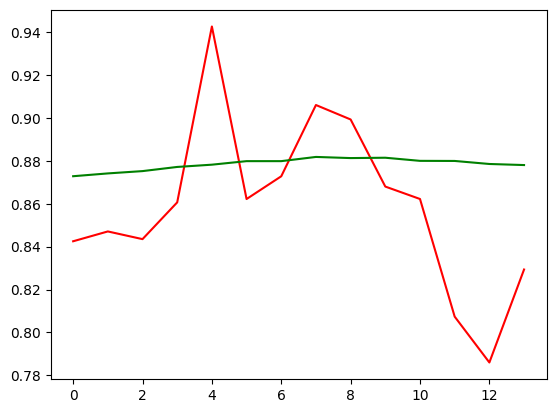

In [126]:
plt.plot(btc_valid[56:56+14], color='red')
plt.plot(predicted_array, color='green')


In [124]:
lstm_model.eval()

# Let's assume 'my_56_days_of_data' is a standard Python list or 1D NumPy array.
# 2. Convert it to a PyTorch tensor and reshape it to (Batch=1, SeqLen=56, Features=1)
input_data = torch.tensor(btc_valid[:56], dtype=torch.float32).view(1, 56, 1)

# 3. Move the input data to the exact same device as the model
input_data = input_data.to(device)

# 4. Run the prediction without tracking gradients (saves memory & speeds it up)
with torch.no_grad():
    raw_prediction = lstm_model(input_data)

# 5. Bring the tensor back to the CPU, remove the batch dimension, and convert to NumPy
predicted_array = raw_prediction.cpu().squeeze().numpy()

print(predicted_array)
print(f"Shape of array: {predicted_array.shape}")

[0.8728452  0.87415504 0.87523305 0.87717295 0.8782309  0.87988025
 0.8798799  0.88184184 0.8813107  0.88147146 0.8800163  0.8799686
 0.8785543  0.87805456]
Shape of array: (14,)


C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\665022303.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_data = torch.tensor(btc_valid[:56], dtype=torch.float32).view(1, 56, 1)
